# 🛍️ ShopEase Analytics Project

# Submitted by:-
1. Himanshu Mohanty (075077)
2. Shreyash Mishra (075104)
3. Ayush Bisht (075115)

## Dynamic Analytical Dashboard with Python

This notebook presents an end-to-end analytics workflow for the **ShopEase retail orders dataset**.

### Project workflow
1. Import the required Python libraries.
2. Load and inspect the raw dataset.
3. Clean and prepare the data.
4. Generate descriptive statistics.
5. Create visualizations to identify patterns.
6. Perform inferential statistical analysis.
7. Build a multiple regression model.
8. Generate a Streamlit dashboard.
9. Export the cleaned dataset and dashboard files.

## 1. Project Setup and Reproducibility

In this section, we import the libraries used throughout the project and set a fixed random seed.

A fixed seed makes randomized operations reproducible, which is important when the project requires a consistent sample or repeatable results.

In [24]:
!pip install streamlit pandas numpy matplotlib seaborn scipy statsmodels

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
GROUP_ID = 77104115
random.seed(GROUP_ID)
np.random.seed(GROUP_ID)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Loading the Raw Dataset

The raw ShopEase orders file is loaded into a Pandas DataFrame.  
We first inspect the dataset dimensions and preview the first few records to understand its structure.

In [25]:
df = pd.read_csv('shopease_raw_orders.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (10020, 16)

First 5 rows:


,OrderID,CustomerID,Order Date,Customer Age,Gender,City,Category,Product,Quantity,Unit Price,Discount,Payment Method,Order Status,DeliveryDate,Rating,Total Amount
0,18129,C0507,01-02-2026 23:39,68.0,Female,Alexandria,Electronics,Laptop,4,18000,0,Wallet,Delivered,04-02-2026 23:39,5.0,72000.0
1,11666,C0207,03-03-2026 10:37,21.0,Female,Cairo,Sports,Yoga Mat,2,600,0.1,Wallet,Delivered,07-03-2026 10:37,1.0,1080.0
2,12859,C1112,23-05-2026 17:57,23.0,Male,Aswan,Fashion,Shoes,-1,1500,10%,Bank Transfer,Delivered,27-05-2026 17:57,4.0,1350.0
3,19787,C1322,29-01-2026 07:51,23.0,Male,Tanta,Beauty,Hair Dryer,4,1300,0.1,Wallet,Delivered,30-01-2026 07:51,4.0,4680.0
4,16473,C0314,23-06-2026 20:17,62.0,Female,Tanta,Electronics,Laptop,1,18000,0.1,Mastercard,Delivered,27-06-2026 20:17,5.0,16200.0


## 3. Initial Data Quality Assessment

Before cleaning, we examine:
- Data types of all variables
- Missing values in each column
- Basic descriptive statistics

This helps identify formatting issues, incomplete observations, and variables that need conversion.

In [26]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
df.describe(include='all')

DATA TYPES
OrderID             int64
CustomerID         object
Order Date         object
Customer Age      float64
Gender             object
City               object
Category           object
Product            object
Quantity            int64
Unit Price          int64
Discount           object
Payment Method     object
Order Status       object
DeliveryDate       object
Rating            float64
Total Amount      float64
dtype: object

MISSING VALUES
OrderID              0
CustomerID          15
Order Date           0
Customer Age       120
Gender               0
City                 0
Category             0
Product             20
Quantity             0
Unit Price           0
Discount           100
Payment Method      50
Order Status         0
DeliveryDate      2230
Rating            2292
Total Amount         0
dtype: int64

BASIC STATISTICS


,OrderID,CustomerID,Order Date,Customer Age,Gender,City,Category,Product,Quantity,Unit Price,Discount,Payment Method,Order Status,DeliveryDate,Rating,Total Amount
count,10020.000000,10005,10020,9900.000000,10020,10020,10020,10000,10020.000000,10020.000000,9920,9970,10020,7790,7728.000000,10020.000000
unique,NaN,1988,9574,NaN,10,30,20,90,NaN,NaN,10,20,13,7653,NaN,NaN
top,NaN,C1257,not available,NaN,Female,Cairo,Home,Coffee Maker,NaN,NaN,0,Cash,Delivered,28-04-2026 05:02,NaN,NaN
freq,NaN,14,10,NaN,4839,3620,1987,440,NaN,NaN,3337,2012,7636,3,NaN,NaN
mean,14999.295908,NaN,NaN,44.381212,NaN,NaN,NaN,NaN,1.947605,1956.412176,NaN,NaN,NaN,NaN,3.958851,3308.779741
std,2888.444735,NaN,NaN,15.703142,NaN,NaN,NaN,NaN,1.100476,5403.755496,NaN,NaN,NaN,NaN,1.023657,7328.702149
min,10001.000000,NaN,NaN,-3.000000,NaN,NaN,NaN,NaN,-3.000000,-500.000000,NaN,NaN,NaN,NaN,-1.000000,200.000000
25%,12496.750000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,1.000000,650.000000,NaN,NaN,NaN,NaN,3.000000,855.000000
50%,14998.500000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,2.000000,900.000000,NaN,NaN,NaN,NaN,4.000000,1600.000000
75%,17501.250000,NaN,NaN,58.000000,NaN,NaN,NaN,NaN,3.000000,1500.000000,NaN,NaN,NaN,NaN,5.000000,2853.250000


## 4. Standardizing Column Names

Column names are stripped of leading and trailing whitespace so that they can be referenced consistently in later analysis.

In [27]:
# Strip whitespace from column names
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

Columns: ['OrderID', 'CustomerID', 'Order Date', 'Customer Age', 'Gender', 'City', 'Category', 'Product', 'Quantity', 'Unit Price', 'Discount', 'Payment Method', 'Order Status', 'DeliveryDate', 'Rating', 'Total Amount']


### 4.1 Cleaning Categorical Variables

Text-based variables such as gender, city, category, product, and payment method are standardized.

The cleaning process improves consistency by:
- Removing unnecessary spaces
- Standardizing capitalization
- Converting inconsistent labels into common categories

In [28]:
# Clean Gender
df['Gender'] = df['Gender'].astype(str).str.strip().str.upper()
df['Gender'] = df['Gender'].replace({
    'M': 'Male', 'F': 'Female', 'MALE': 'Male', 'FEMALE': 'Female'
})

# Clean City
df['City'] = df['City'].astype(str).str.strip().str.title()

# Clean Category
df['Category'] = df['Category'].astype(str).str.strip().str.title()

# Clean Product
df['Product'] = df['Product'].astype(str).str.strip()

# Clean Payment Method
df['Payment Method'] = df['Payment Method'].astype(str).str.strip().str.title()

# Clean Order Status
df['Order Status'] = df['Order Status'].astype(str).str.strip().str.title()
df['Order Status'] = df['Order Status'].replace({
    'Canceled': 'Cancelled', 'Delivered': 'Delivered',
    'Pending': 'Pending', 'Cancelled': 'Cancelled'
})

print("Text columns cleaned.")
print(df['Gender'].value_counts())
print(df['City'].value_counts())
print(df['Order Status'].value_counts())

Text columns cleaned.
Gender
Male      5016
Female    5004
Name: count, dtype: int64
City
Cairo         3766
Giza          2026
Alexandria    1743
Mansoura      1082
Tanta          825
Aswan          578
Name: count, dtype: int64
Order Status
Delivered    7825
Pending      1213
Cancelled     982
Name: count, dtype: int64


### 4.2 Cleaning the Discount Variable

Discount values may appear as percentages, decimals, blank entries, or text values.

The helper function converts these formats into a consistent numeric representation so that discounts can be used in calculations.

In [29]:
def clean_discount(val):
    if pd.isna(val):
        return 0.0
    val = str(val).strip()
    if val == '':
        return 0.0
    if '%' in val:
        return float(val.replace('%', '')) / 100
    try:
        return float(val)
    except:
        return 0.0

df['Discount'] = df['Discount'].apply(clean_discount)
print("Discount cleaned. Unique values:", sorted(df['Discount'].unique()))

Discount cleaned. Unique values: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2)]


### 4.3 Validating Numeric Variables

Numeric fields are converted into appropriate numeric formats and invalid observations are removed.

Examples of validation rules include:
- Quantity must be positive.
- Unit price must be positive.
- Extreme unit-price values are filtered.
- Rating values are restricted to the valid 1–5 scale.

In [30]:
# Quantity: remove negatives and zeros (keep positive only for valid orders)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df = df[df['Quantity'] > 0]

# Unit Price: remove outliers (0, negative, and extreme values like 75000, 100000, 150000)
df['Unit Price'] = pd.to_numeric(df['Unit Price'], errors='coerce')
df = df[df['Unit Price'] > 0]
df = df[df['Unit Price'] < 50000]  # Remove extreme outliers

# Rating: keep only 1-5
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df = df[(df['Rating'] >= 1) & (df['Rating'] <= 5)]

# Customer Age: keep realistic range 18-100
df['Customer Age'] = pd.to_numeric(df['Customer Age'], errors='coerce')
df = df[(df['Customer Age'] >= 18) & (df['Customer Age'] <= 100)]

print("After cleaning outliers, shape:", df.shape)

After cleaning outliers, shape: (7519, 16)


### 4.4 Parsing Date Variables

Order dates may appear in multiple formats.  
The date-parsing function attempts several formats and converts invalid or unavailable values into missing datetime values.

In [31]:
def parse_date(val):
    if pd.isna(val):
        return pd.NaT
    val = str(val).strip()
    if val in ['', 'not available', 'nan']:
        return pd.NaT
    # Try multiple formats
    for fmt in ['%d-%m-%Y %H:%M', '%d-%m-%Y', '%b %d %Y', '%Y-%m-%d', '%d/%m/%Y']:
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            continue
    try:
        return pd.to_datetime(val)
    except:
        return pd.NaT

df['Order Date'] = df['Order Date'].apply(parse_date)
df['DeliveryDate'] = df['DeliveryDate'].apply(parse_date)

# Drop rows with invalid Order Date
df = df.dropna(subset=['Order Date'])

print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())

Date range: 2026-01-01 00:00:00 to 2026-06-29 23:40:00


### 4.5 Recalculating Total Amount

Total order value is recalculated using the business

Recalculating this variable ensures that the final amount is consistent with the cleaned quantity, price, and discount fields.

In [32]:
# Recalculate Total Amount = Quantity * Unit Price * (1 - Discount)
df['Total Amount'] = df['Quantity'] * df['Unit Price'] * (1 - df['Discount'])
df['Total Amount'] = df['Total Amount'].round(2)

print("Total Amount recalculated.")
df[['Quantity', 'Unit Price', 'Discount', 'Total Amount']].head()

Total Amount recalculated.


,Quantity,Unit Price,Discount,Total Amount
0,4,18000,0.0,72000.0
1,2,600,0.1,1080.0
3,4,1300,0.1,4680.0
4,1,18000,0.1,16200.0
5,4,1200,0.1,4320.0


### 4.6 Handling Missing Values

Missing values are handled according to the type of variable:

- Numeric variables: missing values are filled using the median.
- Categorical variables: missing values are filled using the mode.
- Records without a CustomerID are removed because the customer identifier is important for customer-level analysis.

In [33]:
print("Missing values after cleaning:")
print(df.isnull().sum())

# For numerical columns, fill with median
df['Customer Age'].fillna(df['Customer Age'].median(), inplace=True)
df['Rating'].fillna(df['Rating'].median(), inplace=True)

# For text columns, fill with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['City'].fillna(df['City'].mode()[0], inplace=True)

# CustomerID - drop rows without it (or fill with 'Unknown')
df = df.dropna(subset=['CustomerID'])

print("Final shape after cleaning:", df.shape)

Missing values after cleaning:
OrderID            0
CustomerID        13
Order Date         0
Customer Age       0
Gender             0
City               0
Category           0
Product            0
Quantity           0
Unit Price         0
Discount           0
Payment Method     0
Order Status       0
DeliveryDate      30
Rating             0
Total Amount       0
dtype: int64
Final shape after cleaning: (7487, 16)


### 4.7 Exporting the Cleaned Dataset

The cleaned DataFrame is saved as `shopease_cleaned.csv`.

This file is later used by the Streamlit dashboard so that the dashboard operates on the prepared dataset rather than the raw data.

In [34]:
df.to_csv('shopease_cleaned.csv', index=False)
print("Cleaned dataset saved as 'shopease_cleaned.csv'")

# Download it
from google.colab import files
files.download('shopease_cleaned.csv')

Cleaned dataset saved as 'shopease_cleaned.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Descriptive Statistics

Descriptive analysis summarizes the characteristics of the dataset.

### Non-categorical variables
We examine:
- Count
- Mean and median
- Minimum and maximum
- Quartiles
- Standard deviation

### Categorical variables
We examine:
- Category frequencies
- Relative frequencies
- Most and least common categories

These summaries help identify the scale, spread, and composition of the ShopEase dataset.

In [35]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS - NON-CATEGORICAL")
print("=" * 60)
numeric_cols = ['Customer Age', 'Quantity', 'Unit Price', 'Discount', 'Rating', 'Total Amount']
print(df[numeric_cols].describe())

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS - CATEGORICAL")
print("=" * 60)
cat_cols = ['Gender', 'City', 'Category', 'Payment Method', 'Order Status']
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Relative Frequency:\n{df[col].value_counts(normalize=True).round(3)}")

DESCRIPTIVE STATISTICS - NON-CATEGORICAL
       Customer Age     Quantity    Unit Price     Discount       Rating  \
count   7487.000000  7487.000000   7487.000000  7487.000000  7487.000000   
mean      44.402698     1.985976   1807.426205     0.067230     3.960331   
std       15.261541     1.058377   3468.697319     0.061807     1.012691   
min       18.000000     1.000000    250.000000     0.000000     1.000000   
25%       31.000000     1.000000    650.000000     0.000000     3.000000   
50%       45.000000     2.000000    900.000000     0.050000     4.000000   
75%       58.000000     3.000000   1500.000000     0.100000     5.000000   
max       70.000000     4.000000  18000.000000     0.200000     5.000000   

       Total Amount  
count   7487.000000  
mean    3318.029251  
std     7318.873859  
min      200.000000  
25%      880.000000  
50%     1600.000000  
75%     2880.000000  
max    72000.000000  

DESCRIPTIVE STATISTICS - CATEGORICAL

Gender:
Gender
Male      3771
Female 

## 6. Exploratory Data Visualization

Visualizations make patterns easier to interpret than tables alone.

The notebook includes:
- **Histogram:** distribution of total order amounts
- **Box plot:** comparison of total amounts across product categories
- **Count plot:** number of orders across cities
- Additional plots for understanding categorical and numeric variables

These charts support the identification of skewness, unusual observations, category differences, and concentration of orders.

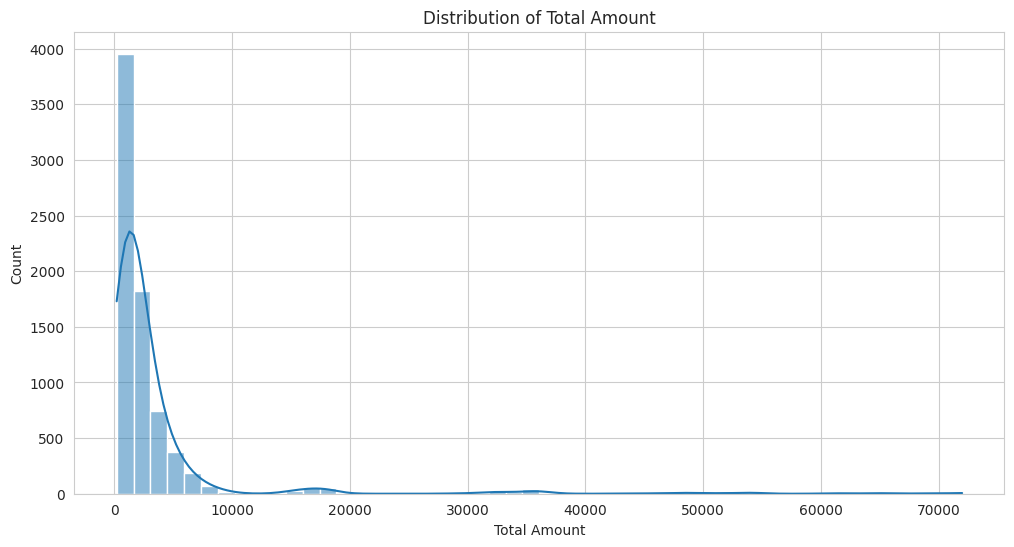

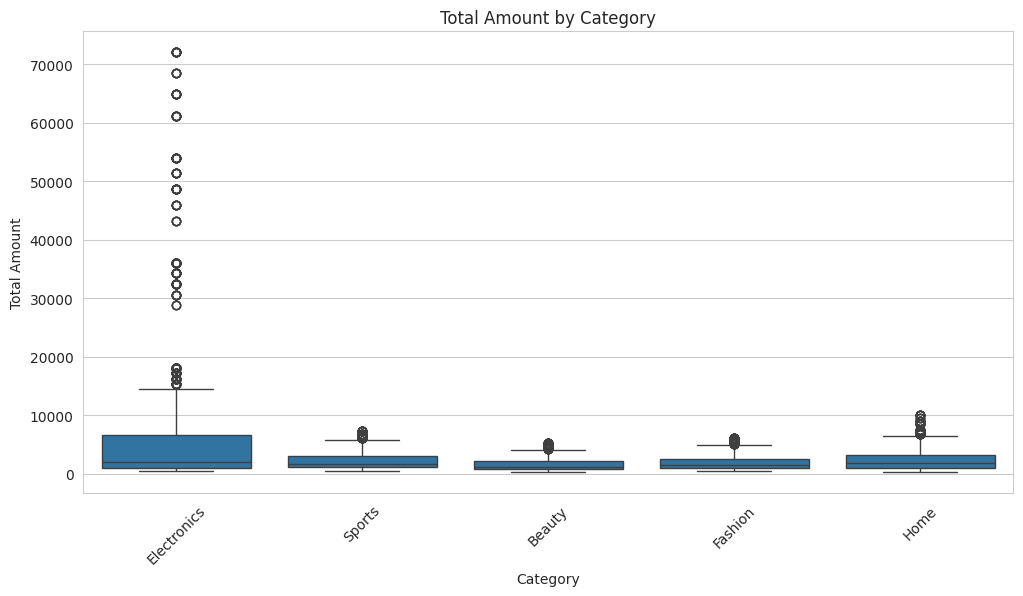

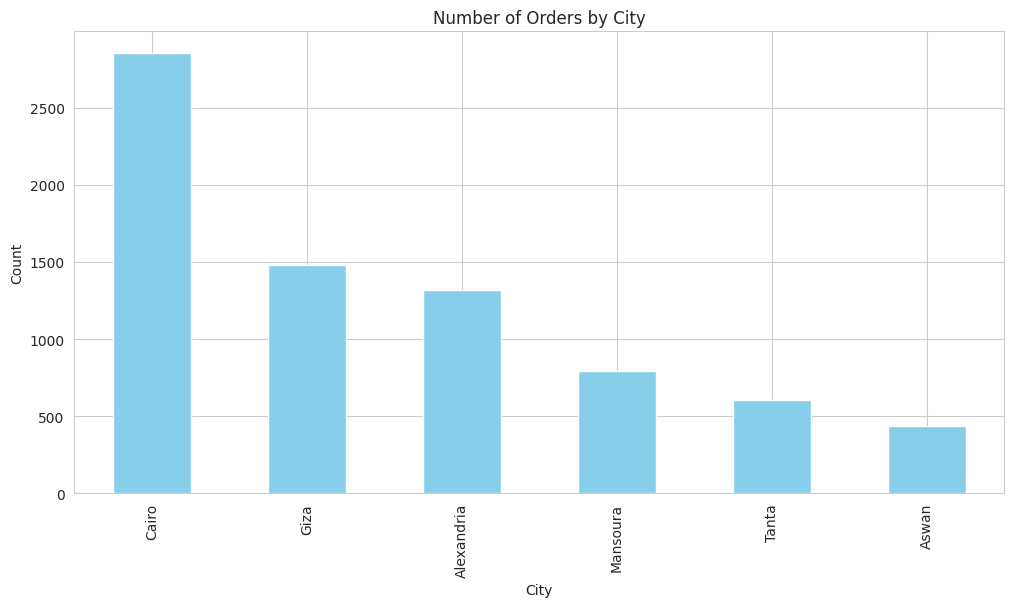

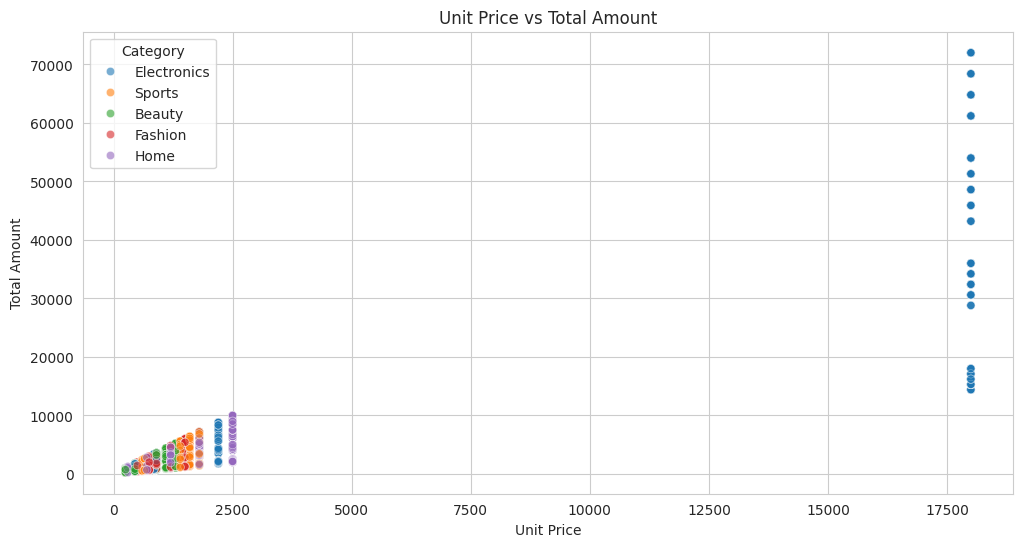

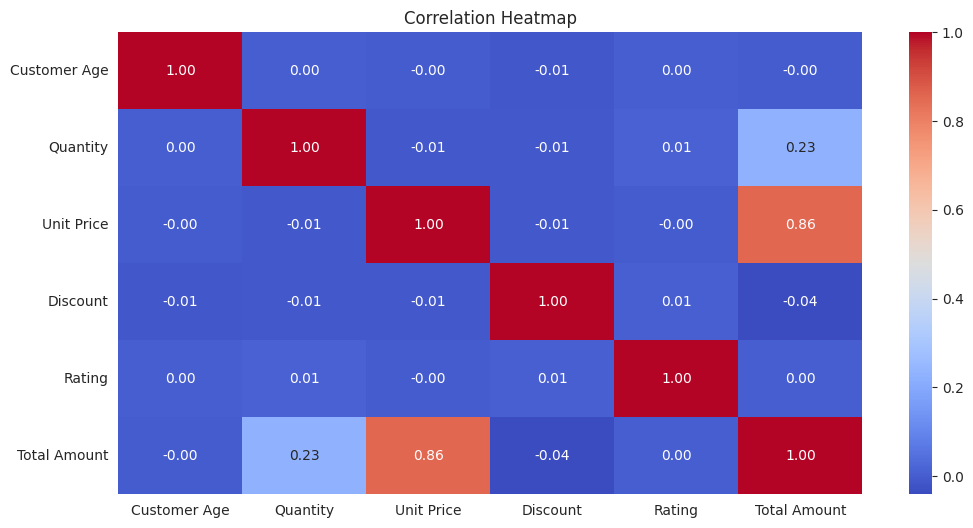

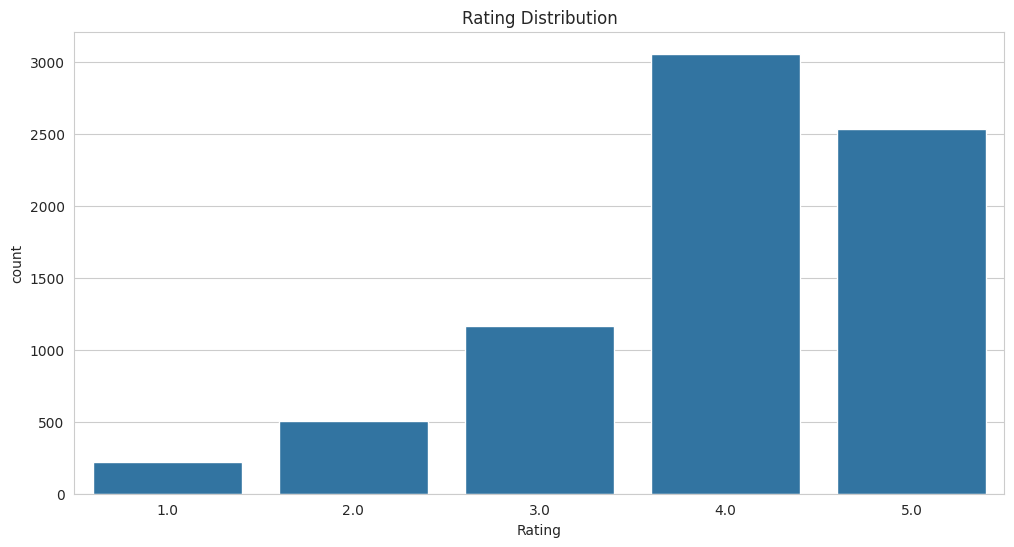

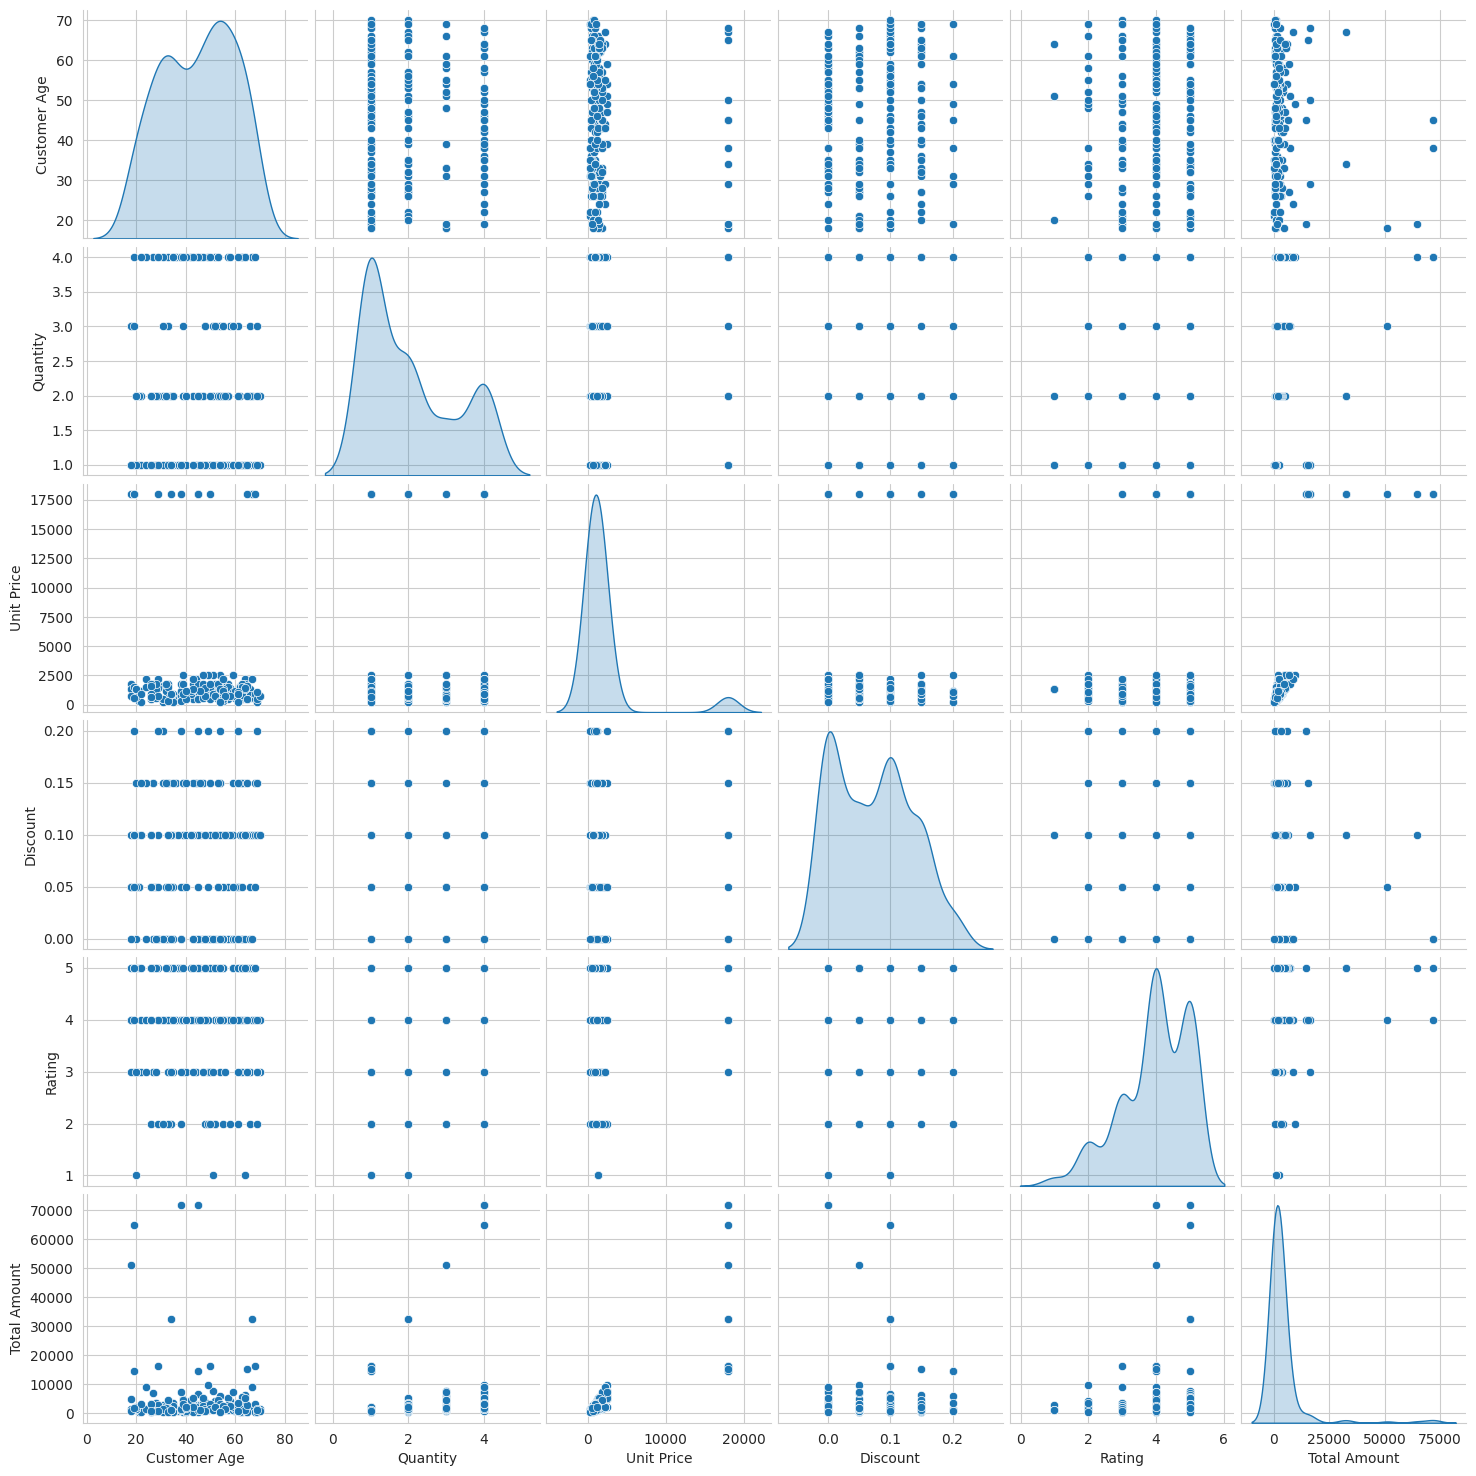

In [36]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Distribution of Total Amount
plt.figure()
sns.histplot(df['Total Amount'], bins=50, kde=True)
plt.title('Distribution of Total Amount')
plt.xlabel('Total Amount')
plt.show()

# 2. Boxplot of Total Amount by Category
plt.figure()
sns.boxplot(x='Category', y='Total Amount', data=df)
plt.title('Total Amount by Category')
plt.xticks(rotation=45)
plt.show()

# 3. Count of Orders by City
plt.figure()
df['City'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Number of Orders by City')
plt.ylabel('Count')
plt.show()

# 4. Scatter plot: Unit Price vs Total Amount
plt.figure()
sns.scatterplot(x='Unit Price', y='Total Amount', hue='Category', data=df, alpha=0.6)
plt.title('Unit Price vs Total Amount')
plt.show()

# 5. Correlation Heatmap
plt.figure()
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 6. Rating Distribution
plt.figure()
sns.countplot(x='Rating', data=df)
plt.title('Rating Distribution')
plt.show()

# 7. Pair Plot
sns.pairplot(df[numeric_cols].sample(200), diag_kind='kde')
plt.show()

## 7. Inferential Statistics

Inferential statistics are used to draw conclusions about the broader dataset based on sample information.

The analysis includes:
- A 95% confidence interval for total order amount
- A two-sample t-test comparing total amounts between male and female customers
- Additional statistical tests included in the code

The p-value is interpreted alongside the chosen significance level, commonly 5%.

In [37]:
print("=" * 60)
print("INFERENTIAL STATISTICS")
print("=" * 60)

# Confidence Interval for Total Amount
mean_amt = df['Total Amount'].mean()
sem_amt = stats.sem(df['Total Amount'])
ci = stats.t.interval(0.95, len(df)-1, loc=mean_amt, scale=sem_amt)
print(f"95% CI for Total Amount: {ci}")

# t-test: Is there a difference in Total Amount between Male and Female?
male = df[df['Gender'] == 'Male']['Total Amount']
female = df[df['Gender'] == 'Female']['Total Amount']
t_stat, p_val = stats.ttest_ind(male, female)
print(f"\nt-test (Gender vs Total Amount): t={t_stat:.3f}, p={p_val:.4f}")

# ANOVA: Total Amount across Categories
categories = [group['Total Amount'].values for name, group in df.groupby('Category')]
f_stat, p_val = stats.f_oneway(*categories)
print(f"ANOVA (Category vs Total Amount): F={f_stat:.3f}, p={p_val:.4f}")

# Chi-square: Gender vs Order Status
contingency = pd.crosstab(df['Gender'], df['Order Status'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square (Gender vs Order Status): chi2={chi2:.3f}, p={p:.4f}")

# Normality Test (Shapiro-Wilk) on sample
sample = df['Total Amount'].sample(500, random_state=GROUP_ID)
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"Shapiro-Wilk Normality Test: W={shapiro_stat:.3f}, p={shapiro_p:.4f}")

# Pearson & Spearman Correlation
pearson_r, pearson_p = stats.pearsonr(df['Unit Price'], df['Total Amount'])
spearman_r, spearman_p = stats.spearmanr(df['Unit Price'], df['Total Amount'])
print(f"Pearson Correlation (Unit Price vs Total Amount): r={pearson_r:.3f}, p={pearson_p:.4f}")
print(f"Spearman Correlation: r={spearman_r:.3f}, p={spearman_p:.4f}")

INFERENTIAL STATISTICS
95% CI for Total Amount: (np.float64(3152.2200367509304), np.float64(3483.8384646515005))

t-test (Gender vs Total Amount): t=0.100, p=0.9200
ANOVA (Category vs Total Amount): F=288.685, p=0.0000
Chi-square (Gender vs Order Status): chi2=0.000, p=1.0000
Shapiro-Wilk Normality Test: W=0.320, p=0.0000
Pearson Correlation (Unit Price vs Total Amount): r=0.857, p=0.0000
Spearman Correlation: r=0.755, p=0.0000


## 8. Regression Analysis

Regression analysis examines how selected variables are associated with total order amount.

### Simple linear regression
The first model uses:

\[
\text{Total Amount} = \beta_0 + \beta_1(\text{Unit Price}) + \epsilon
\]

### Multiple regression
The second model uses:
- Quantity
- Unit Price
- Discount
- Customer Age
- Rating

The regression summary provides coefficients, statistical significance, model fit measures, and other diagnostic information.

In [38]:
# Simple Linear Regression: Total Amount ~ Unit Price
X = df['Unit Price']
y = df['Total Amount']
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

# Multiple Regression
X_multi = df[['Quantity', 'Unit Price', 'Discount', 'Customer Age', 'Rating']]
X_multi_const = sm.add_constant(X_multi)
model_multi = sm.OLS(df['Total Amount'], X_multi_const).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:           Total Amount   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                 2.067e+04
Date:                Wed, 16 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:26:07   Log-Likelihood:                -72285.
No. Observations:                7487   AIC:                         1.446e+05
Df Residuals:                    7485   BIC:                         1.446e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.4633     49.184      1.026      0.3

## 9. Streamlit Dashboard Application

This section creates the Streamlit application file, `app.py`.

The dashboard is designed to make the analysis interactive and user-friendly. It can be used to explore the cleaned ShopEase dataset through filters, summary metrics, tables, and visualizations.

The dashboard uses the cleaned CSV file generated earlier in the notebook.

In [39]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

st.set_page_config(page_title="ShopEase Analytics Dashboard", layout="wide")

@st.cache_data
def load_data():
    df = pd.read_csv('shopease_cleaned.csv')
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'], errors='coerce')
    return df

df = load_data()

# Sidebar Filters
st.sidebar.header("🔍 Filters")

city_filter = st.sidebar.multiselect("City", options=sorted(df['City'].unique()), default=sorted(df['City'].unique()))
category_filter = st.sidebar.multiselect("Category", options=sorted(df['Category'].unique()), default=sorted(df['Category'].unique()))
gender_filter = st.sidebar.multiselect("Gender", options=sorted(df['Gender'].unique()), default=sorted(df['Gender'].unique()))
status_filter = st.sidebar.multiselect("Order Status", options=sorted(df['Order Status'].unique()), default=sorted(df['Order Status'].unique()))

age_range = st.sidebar.slider("Customer Age", int(df['Customer Age'].min()), int(df['Customer Age'].max()), (18, 80))
price_range = st.sidebar.slider("Unit Price", float(df['Unit Price'].min()), float(df['Unit Price'].max()), (float(df['Unit Price'].min()), float(df['Unit Price'].max())))

# Apply filters
filtered = df[
    (df['City'].isin(city_filter)) &
    (df['Category'].isin(category_filter)) &
    (df['Gender'].isin(gender_filter)) &
    (df['Order Status'].isin(status_filter)) &
    (df['Customer Age'].between(age_range[0], age_range[1])) &
    (df['Unit Price'].between(price_range[0], price_range[1]))
]

# Header
st.title("🛍️ ShopEase Dynamic Analytical Dashboard")
st.markdown(f"**Filtered Records:** {len(filtered)} / {len(df)}")

# KPI Metrics
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Revenue", f"${filtered['Total Amount'].sum():,.0f}")
col2.metric("Total Orders", f"{len(filtered):,}")
col3.metric("Avg Order Value", f"${filtered['Total Amount'].mean():,.2f}")
col4.metric("Avg Rating", f"{filtered['Rating'].mean():.2f} ⭐")

st.markdown("---")

# Tabs
tab1, tab2, tab3, tab4 = st.tabs(["📊 Visualizations", "📈 Statistics", "🔬 Inferential Tests", "📋 Data"])

with tab1:
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Revenue by Category")
        fig, ax = plt.subplots()
        filtered.groupby('Category')['Total Amount'].sum().plot(kind='bar', ax=ax, color='teal')
        plt.xticks(rotation=45)
        st.pyplot(fig)

    with col2:
        st.subheader("Orders by City")
        fig, ax = plt.subplots()
        filtered['City'].value_counts().plot(kind='bar', ax=ax, color='coral')
        plt.xticks(rotation=45)
        st.pyplot(fig)

    col3, col4 = st.columns(2)

    with col3:
        st.subheader("Total Amount Distribution")
        fig, ax = plt.subplots()
        sns.histplot(filtered['Total Amount'], bins=40, kde=True, ax=ax, color='purple')
        st.pyplot(fig)

    with col4:
        st.subheader("Boxplot: Amount by Category")
        fig, ax = plt.subplots()
        sns.boxplot(x='Category', y='Total Amount', data=filtered, ax=ax)
        plt.xticks(rotation=45)
        st.pyplot(fig)

    col5, col6 = st.columns(2)

    with col5:
        st.subheader("Rating Distribution")
        fig, ax = plt.subplots()
        sns.countplot(x='Rating', data=filtered, ax=ax, palette='viridis')
        st.pyplot(fig)

    with col6:
        st.subheader("Correlation Heatmap")
        numeric_cols = ['Customer Age', 'Quantity', 'Unit Price', 'Discount', 'Rating', 'Total Amount']
        fig, ax = plt.subplots()
        sns.heatmap(filtered[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
        st.pyplot(fig)

    st.subheader("Scatter: Unit Price vs Total Amount")
    fig, ax = plt.subplots()
    sns.scatterplot(x='Unit Price', y='Total Amount', hue='Category', data=filtered, alpha=0.6, ax=ax)
    st.pyplot(fig)

with tab2:
    st.subheader("Descriptive Statistics")
    numeric_cols = ['Customer Age', 'Quantity', 'Unit Price', 'Discount', 'Rating', 'Total Amount']
    st.dataframe(filtered[numeric_cols].describe())

    st.subheader("Categorical Summary")
    for col in ['Gender', 'City', 'Category', 'Payment Method', 'Order Status']:
        st.write(f"**{col}:**")
        st.dataframe(filtered[col].value_counts().reset_index().rename(columns={'index': col, col: 'Count'}))

with tab3:
    st.subheader("Hypothesis Tests")

    if len(filtered) > 10:
        male = filtered[filtered['Gender'] == 'Male']['Total Amount']
        female = filtered[filtered['Gender'] == 'Female']['Total Amount']
        if len(male) > 2 and len(female) > 2:
            t_stat, p_val = stats.ttest_ind(male, female)
            st.write(f"**t-test (Gender vs Total Amount):** t = {t_stat:.3f}, p = {p_val:.4f}")
            if p_val < 0.05:
                st.success("Reject H₀: Significant difference between genders.")
            else:
                st.info("Fail to reject H₀: No significant difference.")

        cats = [g['Total Amount'].values for _, g in filtered.groupby('Category')]
        if len(cats) > 1:
            f_stat, p_val = stats.f_oneway(*cats)
            st.write(f"**ANOVA (Category vs Total Amount):** F = {f_stat:.3f}, p = {p_val:.4f}")

        contingency = pd.crosstab(filtered['Gender'], filtered['Order Status'])
        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            chi2, p, dof, _ = stats.chi2_contingency(contingency)
            st.write(f"**Chi-square (Gender vs Order Status):** χ² = {chi2:.3f}, p = {p:.4f}")

        pearson_r, pearson_p = stats.pearsonr(filtered['Unit Price'], filtered['Total Amount'])
        st.write(f"**Pearson Correlation (Unit Price vs Total Amount):** r = {pearson_r:.3f}, p = {pearson_p:.4f}")

with tab4:
    st.subheader("Filtered Data")
    st.dataframe(filtered)
    st.download_button("Download Filtered CSV", filtered.to_csv(index=False), "filtered_data.csv")

Overwriting app.py


## 10. Installing Streamlit

Streamlit is installed so that the dashboard can be launched from the notebook environment.

In [40]:
!pip install streamlit

## 11. Launching the Dashboard

The following commands:
- Start the Streamlit application.
- Expose the local dashboard port.
- Generate a public tunnel link for access from a browser.

The dashboard link should be included in the final project submission where required.

In [41]:
!npm install -g localtunnel
!streamlit run app.py &>/dev/null &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 2s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://clever-ends-eat.loca.lt
^C


## 12. Downloading Project Deliverables

The dashboard Python file and cleaned dataset are downloaded for submission, sharing, or deployment.

In [42]:
from google.colab import files

files.download('app.py')
files.download('shopease_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Project Requirements File

The `requirements.txt` file lists the Python libraries needed to reproduce the analysis and run the Streamlit dashboard.

Keeping dependencies in one file makes the project easier to set up on another system.

In [43]:
%%writefile requirements.txt
streamlit
pandas
numpy
matplotlib
seaborn
scipy
statsmodels

Overwriting requirements.txt


## 14. Conclusion

This notebook demonstrates a complete data analytics pipeline, beginning with raw retail order data and ending with an interactive analytical dashboard.

The project combines:
- Data cleaning and validation
- Descriptive statistics
- Exploratory visualization
- Inferential testing
- Regression analysis
- Streamlit dashboard development